# Ejercicios Modulo 5. Excel y CSV (Enunciado)

Consideraciones a tener en cuenta: 

* Guardar este documento con el siguiente formato para su entrega: __M5_02_nombre_apellido1_apellido2__
* Realizar los ejercicios con las herramientas vistas en las sesiones. 
* Comentar el código
* Utilizar nombres de variables apropiados, si vais a guardar una nota, llamar a esa variable nota, no n o x

__Recomendación:__ Haz una copia de los ficheros antes de empezar a modificarlos para siempre poder recuperar una versión original de los mismos.

## EXCEL

**1) Ejercicio de manejo de Excel en base al fichero 02_Excel_data.xlsx:**
* Abre el fichero Excel
* Lista las hojas que hay
* Crea una nueva hoja que se llame olimpiadas entre ventas y otros
* Vuelve a listar las hojas que hay
* Guarda los cambios y comprueba en el excel si se han efectuado

In [16]:
import openpyxl

# Cargo el archivo de Excel
wb = openpyxl.load_workbook("02_Excel_data.xlsx")

# Muestro los nombres de las hojas que hay al principio
print("\nNombres de hojas:")
for sheet in wb:
    print(sheet.title)

# Creo una nueva hoja llamada "Olimpiadas" en la posición 2
wb.create_sheet("Olimpiadas", index=2)

# Vuelvo a mostrar las hojas para comprobar que se ha creado
print("\nNombres de hojas:")
for sheet in wb:
    print(sheet.title)

# Guardo los cambios en el archivo
wb.save("02_Excel_data.xlsx")




Nombres de hojas:
direcciones
ventas
Olimpiadas
otros

Nombres de hojas:
direcciones
ventas
Olimpiadas1
Olimpiadas
otros


**2) Continuemos con Excel**
* Crea una lista que contenga los siguientes datos olímpicos (nombre del país y medallas de oro, plata y bronce):
```
USA, 46, 12, 5
China, 38, 20, 7
UK, 29, 7, 7
Russia, 22, 10, 9
South Korea, 13, 3, 2
Germany, 11, 7, 4
```
* Añadir esa lista a la hoja de olimpiadas que creamos en el ejercicio anterior
* Listar por filas y columnas el contenido
* Mover todo el rango de datos una fila hacia abajo (buscar en la documentación como mover rangos)
* Añadir unas cabeceras en la primera línea (que acaba de quedar libre) que sean "Pais", "Oros", "Platas", "Bronces"
* Guarda los cambios y comprueba en el excel si se han efectuado

In [17]:
import openpyxl

# Lista con los datos de las medallas por país
datos_olimpicos = [
    ("USA", 46, 15, 5),
    ("China", 38, 20, 7),
    ("UK", 29, 7, 7),
    ("Russia", 22, 10, 9),
    ("South Korea", 13, 3, 2),
    ("Germany", 11, 7, 4)
]

# Cargo el archivo de Excel
wb = openpyxl.load_workbook("02_Excel_data.xlsx")

# Selecciono la hoja Olimpiadas
hoja = wb["Olimpiadas"]

# Voy metiendo cada fila de datos en la hoja
for fila in datos_olimpicos:
    hoja.append(fila)

# Muestro por pantalla las celdas y su contenido para comprobarlo
for fila in hoja.rows:
    for columna in fila:
        print(columna.coordinate, columna.value)

# Muevo todo el rango una fila hacia abajo para dejar libre la primera fila
hoja.move_range(f"A1:D{hoja.max_row}", rows=1)

# Escribo los nombres de las columnas en la primera fila
hoja["A1"] = "País"
hoja["B1"] = "Oros"
hoja["C1"] = "Platas"
hoja["D1"] = "Bronces"

# Guardo los cambios en el archivo
wb.save("02_Excel_data.xlsx")

A1 Pais
B1 Oros
C1 Platas
D1 Bronces
E1 Total
A2 USA
B2 46
C2 15
D2 5
E2 66
A3 China
B3 38
C3 20
D3 7
E3 65
A4 UK
B4 29
C4 7
D4 7
E4 43
A5 Russia
B5 22
C5 10
D5 9
E5 41
A6 South Korea
B6 13
C6 3
D6 2
E6 18
A7 Germany
B7 11
C7 7
D7 4
E7 22
A8 USA
B8 46
C8 15
D8 5
E8 None
A9 China
B9 38
C9 20
D9 7
E9 None
A10 UK
B10 29
C10 7
D10 7
E10 None
A11 Russia
B11 22
C11 10
D11 9
E11 None
A12 South Korea
B12 13
C12 3
D12 2
E12 None
A13 Germany
B13 11
C13 7
D13 4
E13 None


**3) Continuemos con Excel, centrandonos en la parte de la librería openpyxl.styles (la cual proporciona estilo a nuestras hojas de Excel)**
* Poner las cabeceras que acabamos de añadir en negrita (bold)
* Guarda los cambios y comprueba en el excel si se han efectuado

Pista: Aunque hay varias formas de hacerlo, lo más común es definir el estilo que deseas (negrita) y luego aplicárselo a todas las celdas que quieras (iterar por la primera fila de nuestra hoja)

Doc: https://openpyxl.readthedocs.io/en/stable/styles.html

In [18]:
from openpyxl.styles import Font

# Creo un estilo de letra en negrita
negrita = Font(bold=True)

# Recorro la primera fila (las cabeceras) y aplico la negrita
for celda in hoja[1]:
    celda.font = negrita

# Guardo los cambios en el archivo
wb.save("02_Excel_data.xlsx")

**4) Continuamos con Excel. Crea una nueva columna que sea el sumatorio de todas las medallas conseguidas por cada uno de los paises**

In [19]:
import openpyxl

# Cargo el archivo de Excel
wb = openpyxl.load_workbook("02_Excel_data.xlsx")

# Selecciono la hoja donde están los datos
hoja = wb["Olimpiadas"]

# Pongo el título de la nueva columna
hoja["E1"] = "Total"

# Recorro todas las filas (empiezo en la 2 para saltar los títulos)
for fila in range(2, hoja.max_row + 1):
    
    # Cojo las medallas de cada tipo
    oros = hoja.cell(row=fila, column=2).value
    platas = hoja.cell(row=fila, column=3).value
    bronces = hoja.cell(row=fila, column=4).value

    # Sumo las medallas
    total = oros + platas + bronces

    # Guardo el total en la columna E
    hoja.cell(row=fila, column=5).value = total

# Guardo los cambios en el archivo
wb.save("02_Excel_data.xlsx")

**5) Continuamos con Excel. Crear un gráfico de barras (openpyxl.chart.BarChart()) lo más parecido al que se muestra en la imagen:**

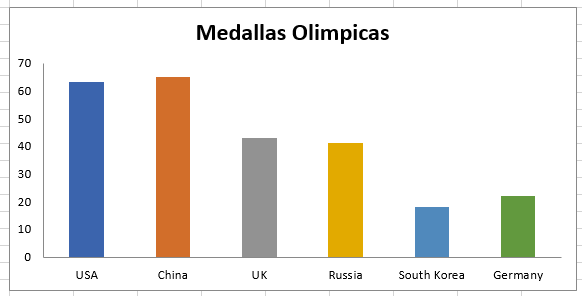

In [15]:
import openpyxl

# Cargo el archivo de Excel
wb = openpyxl.load_workbook("02_Excel_data.xlsx")

# Selecciono la hoja donde están los datos
hoja_olimpiadas = wb["Olimpiadas"]

# Cojo los datos que voy a usar para el gráfico (columna de total de medallas)
data = openpyxl.chart.Reference(hoja_olimpiadas, min_col=5, min_row=1, max_col=5, max_row=7)

# Cojo las categorías (los países)
categs = openpyxl.chart.Reference(hoja_olimpiadas, min_col=1, min_row=2, max_row=7)

# Creo el gráfico de barras
graph = openpyxl.chart.BarChart()
graph.type = "col"  # tipo columnas (barras verticales)
graph.style = 11  # estilo del gráfico
graph.title = "Medallas Olímpicas"

# Títulos de los ejes
graph.x_axis.title = "País"
graph.y_axis.title = "Total Medallas"

# Añado los datos al gráfico
graph.add_data(data, titles_from_data=True)

# Añado las categorías (nombres de países)
graph.set_categories(categs)

# Ajusto el tamaño del gráfico
graph.width = 20
graph.height = 12

# Inserto el gráfico en la hoja en la posición G2
hoja_olimpiadas.add_chart(graph, "G2")

# Guardo los cambios en el archivo
wb.save("02_Excel_data.xlsx")

## CSV

**Vamos a realizar un ejercicio práctico de minería de datos, donde limpiaremos y filtraremos información con un csv que contiene datos de vehículos**

Trabajaremos con el fichero **02_CSV_data.csv**

**6) Observa los datos del csv y realiza las siguientes tareas:**

* Tenemos 9 columnas, las 8 primeras contienen datos numéricos con los cuales podemos trabajar, crea una lista para cada una de estas columnas (mpg, cylinders, etc.). No es necesario crear lista para name
* Recorre los datos del csv adecuadamente y almacena los datos de cada columna en cada una de las listas que has creado anteriormente.
* Comprobar que se haya guardado en las listas la información correspondiente (con prints)

In [12]:
import csv

# Listas donde voy guardando los datos de cada columna
mpg = []
cylinders = []
displacement = []
horsepower = []
weight = []
acceleration = []
year = []
origin = []

# Abro el CSV para leerlo
with open("02_CSV_data.csv", newline="", encoding="utf-8") as f:
    reader = csv.reader(f)

    next(reader)  # me salto la primera fila porque son los nombres de las columnas

    # Recorro todas las filas del archivo
    for row in reader:

        # Guardo cada dato en su lista convirtiéndolo a número
        mpg.append(float(row[0]))  # consumo
        cylinders.append(int(row[1]))  # cilindros
        displacement.append(float(row[2]))  # cilindrada
       
        # A veces horsepower viene vacío, lo controlo para que no falle
        if row[3] != "":
            horsepower.append(float(row[3]))
        else:
            horsepower.append(0)  # si está vacío, pongo 0
        
        weight.append(float(row[4]))  # peso
        acceleration.append(float(row[5]))  # aceleración
        year.append(int(row[6]))  # año
        origin.append(int(row[7]))  # origen

# Imprimo unos pocos valores para comprobar que todo está bien
print("Mpg:", mpg[:5])
print("Cylinders:", cylinders[:5])
print("Displacement:", displacement[:5])
print("Horsepower:", horsepower[:5])
print("Weight:", weight[:5])
print("Acceleration:", acceleration[:5])
print("Year:", year[:5])
print("Origin:", origin[:5])

# También miro cuántos datos se han guardado
print("Número de valores en mpg:", len(mpg))

Mpg: [18.0, 15.0, 18.0, 16.0, 17.0]
Cylinders: [8, 8, 8, 8, 8]
Displacement: [307.0, 350.0, 318.0, 304.0, 302.0]
Horsepower: [130.0, 165.0, 150.0, 150.0, 140.0]
Weight: [3504.0, 3693.0, 3436.0, 3433.0, 3449.0]
Acceleration: [12.0, 11.5, 11.0, 12.0, 10.5]
Year: [70, 70, 70, 70, 70]
Origin: [1, 1, 1, 1, 1]
Número de valores en mpg: 397


**7) Vamos a trabajar con los números de nuestras listas por lo que nos sobra el primer elemento de cada lista, el cual contiene el nombre de cada una de las columnas.**

* Elimina el primer elemento de cada una de las listas
* Observa que los datos de nuestras listas son strings, conviértelos a float. Pista: list y map te pueden ayudar.
* Comprobar que se haya eliminado el primer elemento y que los datos son numéricos (con prints)

In [10]:
import csv

# Listas donde voy a guardar los datos de cada columna
mpg = []
cylinders = []
displacement = []
horsepower = []
weight = []
acceleration = []
year = []
origin = []

# Abro el archivo CSV
with open("02_CSV_data.csv", newline="", encoding="utf-8") as f:
    reader = csv.reader(f)

    next(reader)  # salto la primera fila porque son los nombres de las columnas

    # Recorro todas las filas del archivo
    for row in reader:

        # Voy guardando cada dato en su lista
        mpg.append(float(row[0]))  # consumo
        cylinders.append(int(row[1]))  # cilindros
        displacement.append(float(row[2]))  # cilindrada

        # A veces horsepower viene vacío, lo controlo
        if row[3] != "":
            horsepower.append(float(row[3]))
        else:
            horsepower.append(0)  # si está vacío, meto 0

        weight.append(float(row[4]))  # peso
        acceleration.append(float(row[5]))  # aceleración
        year.append(int(row[6]))  # año
        origin.append(int(row[7]))  # origen

# Imprimo solo los primeros valores para ver que todo está bien
print("Mpg:", mpg[:5])
print("Cylinders:", cylinders[:5])
print("Displacement:", displacement[:5])
print("Horsepower:", horsepower[:5])
print("Weight:", weight[:5])
print("Acceleration:", acceleration[:5])
print("Year:", year[:5])
print("Origin:", origin[:5])

# También compruebo cuántos datos he guardado
print("Total de datos en mpg:", len(mpg))

Mpg: [18.0, 15.0, 18.0, 16.0, 17.0]
Cylinders: [8, 8, 8, 8, 8]
Displacement: [307.0, 350.0, 318.0, 304.0, 302.0]
Horsepower: [130.0, 165.0, 150.0, 150.0, 140.0]
Weight: [3504.0, 3693.0, 3436.0, 3433.0, 3449.0]
Acceleration: [12.0, 11.5, 11.0, 12.0, 10.5]
Year: [70, 70, 70, 70, 70]
Origin: [1, 1, 1, 1, 1]
Total de datos en mpg: 397


**8) Para terminar vamos a mostrar algunos resultados. Para ello utilizaremos la librería statistics.**

* Muestra para cada una de las listas, cuantas observaciones tiene (cuántos datos tiene).
* Mostrar el mínimo y el máximo de cada lista
* Mostrar la media, mediana y desviación estándar de cada lista (utilizando statistics)

In [14]:
import statistics as stats

# Agrupo todas las listas en un diccionario para recorrerlas más fácil
listas = {
    "mpg": mpg,
    "cylinders": cylinders,
    "displacement": displacement,
    "horsepower": horsepower,
    "weight": weight,
    "acceleration": acceleration,
    "year": year,
    "origin": origin,
}

# Recorro cada lista para sacar sus estadísticas
for nombre, lista in listas.items():
    print(f"\n{nombre}:")
    
    # Número de datos que tiene la lista
    print(" Observaciones:", len(lista))
    
    # Valores básicos
    print(" Mínimo:", min(lista))
    print(" Máximo:", max(lista))
    
    # Estadísticas principales
    print(" Media:", stats.mean(lista))
    print(" Mediana:", stats.median(lista))
    print(" Desviación estándar:", stats.stdev(lista))


mpg:
 Observaciones: 397
 Mínimo: 9.0
 Máximo: 46.6
 Media: 23.51586901763224
 Mediana: 23.0
 Desviación estándar: 7.825803928946562

cylinders:
 Observaciones: 397
 Mínimo: 3
 Máximo: 8
 Media: 5.458438287153652
 Mediana: 4
 Desviación estándar: 1.7015769807918462

displacement:
 Observaciones: 397
 Mínimo: 68.0
 Máximo: 455.0
 Media: 193.53274559193954
 Mediana: 146.0
 Desviación estándar: 104.37958329992955

horsepower:
 Observaciones: 397
 Mínimo: 46.0
 Máximo: 230.0
 Media: 104.28715365239294
 Mediana: 92.0
 Desviación estándar: 38.28149540065238

weight:
 Observaciones: 397
 Mínimo: 1613.0
 Máximo: 5140.0
 Media: 2970.2619647355164
 Mediana: 2800.0
 Desviación estándar: 847.9041194897246

acceleration:
 Observaciones: 397
 Mínimo: 8.0
 Máximo: 24.8
 Media: 15.55566750629723
 Mediana: 15.5
 Desviación estándar: 2.749995292976151

year:
 Observaciones: 397
 Mínimo: 70
 Máximo: 82
 Media: 75.99496221662469
 Mediana: 76
 Desviación estándar: 3.690004901461682

origin:
 Observaciones